# Is the number of speakers correlated with a loss in morphological complexity?

**Author:** Maxence Mirosavic

**Date:** May, 2026

This study aims to investigate the factors that lead languages to lose morphological complexity. Previous studies have argued that languages with larger speaker populations tend to exhibit lower morphological complexity (Lupyan & Dale, 2010), while more recent work suggests that historical factors must also be taken into account (Shcherbakova et al., 2023). We therefore seek to evaluate whether speaker population size correlates with morphological simplification once both historical and geographical factors are controlled for. Historical factors are represented here by the depth of a language’s phylogenetic tree, while geographical factors are represented by the number of neighboring languages and the morphological distance between a language and its geographical neighbors.

Moreover, Shcherbakova et al. (2023) distinguish two independent dimensions underlying what is commonly referred to as “morphological complexity”:

* **Fusion**, defined as the extent to which a language encodes multiple grammatical meanings within a single word;
* **Informativity**, defined as the amount of information speakers are obligatorily required to express.

Accordingly, the present study investigates these two dimensions separately in order to determine whether the same explanatory factors influence both aspects of morphological complexity.

## 1. Libraries and Data

For this analysis, we will use data from Grambank, which was already used in Shcherbakova et al. (2023)'s study, which contains morphological data for 2000+ languages. We will combine it with data for the number of speakers given for free by Wikidata.

### 1.1 Importing libraries

In [1]:
import re

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf

In [3]:
from matplotlib.gridspec import GridSpec
from mpl_toolkits.basemap import Basemap
from graphviz import Digraph
from sklearn.neighbors import BallTree
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler

### 1.2 Loading Grambank

In [4]:
url = "https://raw.githubusercontent.com/grambank/grambank/v1.0.3/cldf/languages.csv"
df1 = pd.read_csv(url)

In [5]:
url = "https://github.com/grambank/grambank/raw/v1.0.3/cldf/values.csv"
df2 = pd.read_csv(url)
df2["Value"] = pd.to_numeric(df2["Value"], errors="coerce")

In [6]:
# We need a "language x parameter" matrix instead of a "parameter x language" matrix
df3 = df2.pivot(
    index='Language_ID',
    columns='Parameter_ID',
    values='Value'
)
df3 = df3.reset_index()

In [7]:
df = pd.merge(left=df1, right=df3, left_on='Glottocode', right_on='Language_ID')

### 1.3 Adding Wikidata

In [8]:
# the scrapping is already done to bypass Wikidata's API limitations (namely 1 request / minutes but quite often more too?)
wikidata = pd.read_csv('wikidata.csv')

In [9]:
df = pd.merge(left=df, right=wikidata, left_on='Glottocode', right_on='glottocode')

## 2. Theory and Directed Acyclic Graph

We therefore define our main explanatory variable as the **number of speakers**, and the outcomes are **Fusion** and **Informativity**.

In [10]:
dag = Digraph()
exp_var = ['Number of speakers']
outputs = ['Informativity', 'Fusion']
color = 'lightcoral' # We put in read the main explanatory variable and the outcomes

In [11]:
# Creating the nodes for the variables
dag.node(exp_var[0], shape='ellipse', style='filled', fillcolor=color)
for node in outputs:
    dag.node(node, shape='box', style='filled', fillcolor=color) # outcomes will be box-shaped

As suggested by Shcherbakova et al. (2023), we take into account confounding variables corresponding to both language history and geography :

- **Length of the phylogeny tree** (Phylogeny tree): We use the length of the phylogeny tree of a language to approximate the language's history.

- **Number of neighbors**: We use this variable to account for the harshness of the environment (which creates more linguistic communities within a limited area), which can be a covariate of both the number of speakers and complexity.

- **Morphological distance to the neighbors** (Morphological distance): How much the language share morphological features with its neighbors. It is expected to contain information about how much contact the culture has with its neighbors.

In order to partially account for phylogenetic non-independence between languages, linguistic family was included as a random effect in the regression models. Languages belonging to the same family often share inherited grammatical properties and therefore cannot be considered fully independent observations. Including family-level random intercepts makes it possible to control, at least partially, for this shared phylogenetic structure, as well as the difference in some of them being more or less known and studied (typologically and morphologically) than others

The geographical features are inspired by observations from Urban (2020) and Everett (2013) who show that montainous areas may have effects on linguistic features (namely the use of ejectives (Everett, 2013))

In [12]:
# Creating the nodes for the covariates
covariates = ['Phylogeny tree', 'Number of neighbors', 'Morphological Distance']
color = 'skyblue' # We use blue for the covariates
for node in covariates:
    dag.node(node, shape='ellipse', style='filled', fillcolor=color)

In [13]:
# Creating the edges of the DAG
dag.edge('Number of speakers', 'Informativity')
dag.edge('Number of speakers', 'Fusion')

dag.edge('Phylogeny tree', 'Informativity')
dag.edge('Phylogeny tree', 'Fusion')
dag.edge('Phylogeny tree', 'Number of speakers')

dag.edge('Number of neighbors', 'Number of speakers')
dag.edge('Number of neighbors', 'Informativity')
dag.edge('Number of neighbors', 'Fusion')

dag.edge('Morphological Distance', 'Informativity')
dag.edge('Morphological Distance', 'Fusion')
dag.edge('Morphological Distance', 'Number of speakers')

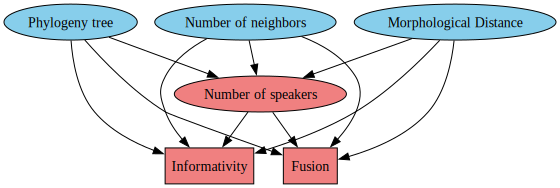

In [14]:
dag.render(
    filename='language_tree',
    format='png',
    cleanup=True
) # We also create a usable png version of the graph
dag

## 3. Data modifications

For this analysis, we will need the data for :

- the **complexity measures** which are calculated in section 3.1 using same columns as used by Shcherbakova et al. You may find them in the annex document on *Science*'s website.

- the **number of speakers** which is converted into a number in section 3.2 and then we only keep the logarithm to keep a gaussian distribution.

- **language history** which is calculated as the length of the phylogeny tree in section 3.3.

- **neighboring languages** which are counted in section 3.4.

- **morphological distance** which is calculated in section 3.5 by vectorizing all the morphological data from Grambank and then calculating the mean value of cosine similarities.

Then, in section 3.6, we keep only the values which will be useful in our analysis (see **Figure 1.**), *i.e.* the name of the language, its latitude, longitude, the logarithm of its number of speakers, the new values previously calculated and then its family name for the random effect.

### 3.1 Complexity measures

In [15]:
# gathering the numbers of the Fusion-related morphological data
nbs = ['148', '070', '091', '092', '093', '094', '095',
       '120', '188', '275', '187', '170', '172', '198',
       '119', '312', '107', '298', '171', '184', '185',
       '186', '043', '166', '044', '042', '165', '147',
       '285', '286', '430', '431', '432', '433', '115',
       '114', '121', '082', '083', '084', '103', '108',
       '104', '149', '152', '151', '072', '079', '080',
       '081', '089', '090', '113', '155', '177']

# We convert them into variables (since all morphological data are in the format 'GB{number}')
cols1 = [f'GB{nb}' for nb in nbs]
df['fusion'] = df[cols1].mean(axis=1) # Then we keep the mean value

In [16]:
# We create a property-level dictionary for Informativity-related morphological data
dic = {
    'antipassive': ['303', '148'],
    'aspect': ['520', '086', '120'],
    'mood': ['519', '119', '312'],
    'dual': ['317', '043'],
    'paucal': ['320', '166'],
    'plural': ['318', '044'],
    'singular': ['316', '042'],
    'trial': ['319', '165'],
    'passive': ['302', '147'],
    'tense': ['521', '121', '082', '083', '084'],
    'control': ['146'],
    'augmentative': ['188', '314'],
    'diminutive': ['187', '315'],
    'reciprocity': ['115', '306'],
    'reflexivity': ['114', '305'],
    'benefactive': ['103'],
    'directional': ['108'],
    'instrumental': ['104'],
    'inverse': ['149'],
    'simultanseq': ['152'],
    'switch reference': ['151'],
    'augmentanimacy': ['177'],
    'alienability': ['059'],
    'numera classifiers': ['057'],
    'possessive classifiers': ['058'],
    'pronoundualaug': ['031'],
    'genderanimacy': ['053'],
    'genderplant': ['054'],
    'gendersex': ['051'],
    'gendershape': ['052'],
    'pronoungender1': ['197'],
    'pronoungender2': ['196'],
    'pronoungender3': ['030'],
    'assocplural': ['046'],
    'clusivity': ['028'],
    'comitative': ['027'],
    'copulaprednom': ['117'],
    'count_mass': ['325'],
    'definitearticles': ['020'],
    'demonstrativedistance': ['035'],
    'demonstrative classifiers': ['038'],
    'demonstrativeelevation': ['036'],
    'demonstrativevisibility': ['037'],
    'differentneg': ['140'],
    'evidentiality_direct': ['322'],
    'evidentiality_indirect': ['323'],
    'existentialverb': ['126'],
    'indef': ['021'],
    'multipletense': ['309'],
    'politeness': ['415'],
    'postureverbs': ['127'],
    'prohibitive': ['139'],
    'pronounlog': ['167'],
    'verbclassify': ['116']
}

In [17]:
# We convert those numbers into variable names
for e in dic.keys():
    cols2 = []
    for e2 in dic[e]:
        cols2.append(f'GB{e2}')
    df[e] = df[cols2].mean(axis=1) # Then we keep the mean value as the morphological value for said property of a language

In [18]:
df['informativity'] = df[dic.keys()].mean(axis=1)

### 3.2 Number of speakers

In [19]:
# Converting to numbers and calculating the logarithm
df['log_speakers'] = np.log10(
    pd.to_numeric(df['n_speakers'], errors='coerce') + 1
)

### 3.3 Language history

In [20]:
# cutting the lineage data on "/"
def cut(txt : str):
    try:
        return list(str(txt).split('/'))
    except TypeError:
        return []

df['lineage_list'] = df['lineage'].apply(cut)

In [21]:
# Then we keep the length of the list that is obtained
df['language_history'] = df['lineage_list'].apply(len)

### 3.4 Neighboring languages

In [22]:
# Creating the data structure to find the closest neighbors
coords = df[['Latitude', 'Longitude']].dropna().to_numpy()
coords_rad = np.radians(coords)
tree = BallTree(coords_rad, metric='haversine') # We create a scikit-learn BallTree class, useful to find neighbors without 
                                                # directly comparing the location of every language in the dataset

In [23]:
radius_km = 500
earth_radius_km = 6371

radius = radius_km / earth_radius_km
neighbors = tree.query_radius(coords_rad, r=radius) # searching for the neighbors given a radius of 500 km

In [24]:
df_neighbors = df[['Latitude', 'Longitude']].dropna().copy()

df_neighbors['neighboring_languages'] = [
    len(n) - 1
    for n in neighbors
] # Adding to df_neighbors the number of neighbours - 1 (the language itself)

In [25]:
df.loc[df_neighbors.index, 'neighboring_languages'] = (
    df_neighbors['neighboring_languages']
) # Adding to df
df['neighboring_languages'] = df['neighboring_languages'].apply(int) # and converting to a number for easier use

### 3.5 Local language morphological similarity

In [26]:
grambank_cols = [
    col for col in df.columns
    if re.match(r'^GB\d{3}$', col)
] # finding all morphological data in df
X = df[grambank_cols].fillna(0).to_numpy() # creating a morphological matrix
D = cosine_distances(X) # calculating the cosine similarities of all the lines of the matrix

In [27]:
# Calculating the mean value of these distances
mean_distances = []

for i, neigh in enumerate(neighbors):

    neigh = neigh[neigh != i]

    if len(neigh) == 0:
        mean_distances.append(np.nan)

    else:
        mean_distances.append(
            D[i, neigh].mean()
        )

In [28]:
df['mean_neighbor_distance'] = mean_distances # Adding to df

### 3.6 Cleaning and checking the dataframe

In [29]:
df = df[['Name', 'Latitude', 'Longitude', 'log_speakers', 'fusion', \
    'informativity', 'language_history', 'neighboring_languages', 'mean_neighbor_distance', \
    'Family_name']] # Keeping only the useful columns

In [30]:
df

,Name,Latitude,Longitude,log_speakers,fusion,informativity,language_history,neighboring_languages,mean_neighbor_distance,Family_name
0,Abadi,-9.033890,146.992000,3.633569,0.315789,0.193548,10,14,0.461614,Austronesian
1,Abau,-3.972220,141.324000,3.861594,0.300000,0.328704,1,11,0.499726,Sepik
2,Abenlen Ayta,15.413100,120.200000,3.477266,0.318182,0.223958,5,13,0.553285,Austronesian
3,Abipon,-29.000000,-61.000000,0.000000,0.595238,0.291667,2,2,0.347330,Guaicuruan
4,Abkhaz,43.056218,41.159115,5.279007,0.509091,0.426797,2,18,0.406816,Abkhaz-Adyge
...,...,...,...,...,...,...,...,...,...,...
874,Lahta-Zayein Karen,20.160000,96.908000,3.968530,0.018182,0.106918,3,13,0.354209,Sino-Tibetan
875,Zigula-Mushungulu,-5.618640,38.411380,5.550230,0.440000,0.082353,13,10,0.479924,Atlantic-Congo
876,Zulgo-Gemzek,10.827000,14.057800,4.414990,0.152174,0.249524,7,15,0.411129,Afro-Asiatic
877,Zulu,-28.900000,30.200000,7.082785,0.642857,0.380952,12,2,0.517822,Atlantic-Congo


## 4. Monovariate representations

In [31]:
x_all = df['Longitude'].values
y_all = df['Latitude'].values

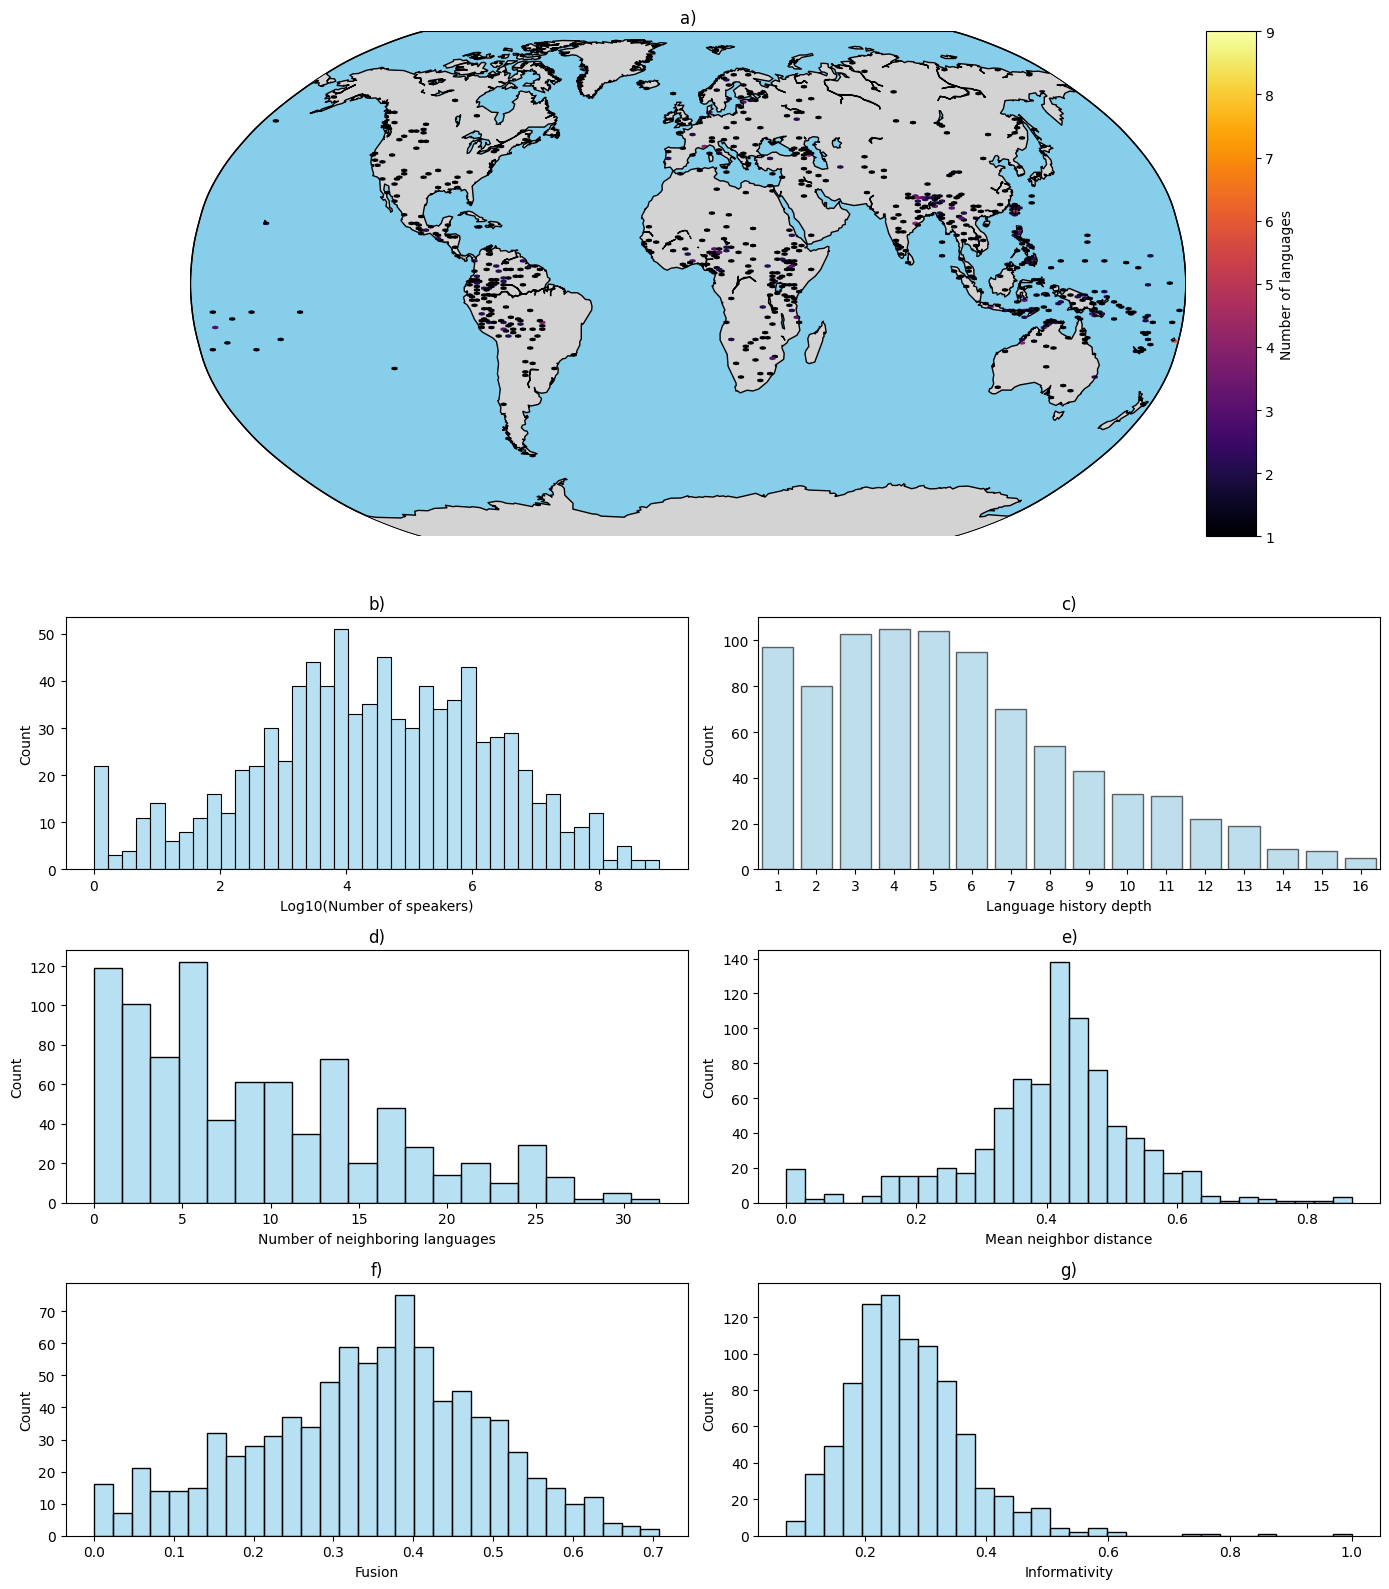

In [32]:
fig = plt.figure(figsize=(14, 16))

gs = GridSpec(
    4, 2,
    height_ratios=[2, 1, 1, 1]
) # Creating a GridSpec class so that the map can be displayed taking two slots instead of only one (too small for readability)

# ==========================================
# MAP
# ==========================================

ax_map = fig.add_subplot(gs[0, :])

m = Basemap(
    projection='robin',
    lat_0=0,
    lon_0=0,
    resolution='c',
    ax=ax_map
)

m.drawcoastlines(color='black')
m.drawmapboundary(fill_color='skyblue')
m.fillcontinents(
    color='lightgray',
    lake_color='skyblue'
)

new_x, new_y = m(x_all, y_all)

hb = m.hexbin(
    x=new_x,
    y=new_y,
    gridsize=200,
    mincnt=1,
    cmap='inferno'
) # creating a hexbin for slightly better readability in areas where lots of languages are spoken

m.colorbar(
    hb,
    label='Number of languages',
    location='right'
)

ax_map.set_title(
    'a)'
)

# ==========================================
# SPEAKERS
# ==========================================

ax_hist = fig.add_subplot(gs[1, 0])

sns.histplot(
    data=df,
    x='log_speakers',
    bins=40,
    edgecolor='black',
    color='skyblue',
    alpha=.6,
    ax=ax_hist
)

ax_hist.set_xlabel(
    "Log10(Number of speakers)"
)

ax_hist.set_ylabel("Count")

ax_hist.set_title(
    "b)"
)

# ==========================================
# LANGUAGE HISTORY
# ==========================================

ax_hist2 = fig.add_subplot(gs[1, 1])

sns.countplot(
    x='language_history',
    data=df,
    edgecolor='black',
    color='skyblue',
    alpha=.6,
    ax=ax_hist2
)

ax_hist2.set_xlabel(
    "Language history depth"
)

ax_hist2.set_ylabel("Count")

ax_hist2.set_title(
    "c)"
)

# ==========================================
# NEIGHBORING LANGUAGES
# ==========================================

ax_hist3 = fig.add_subplot(gs[2, 0])

sns.histplot(
    data=df,
    x='neighboring_languages',
    bins=20,
    edgecolor='black',
    color='skyblue',
    alpha=.6,
    ax=ax_hist3
)

ax_hist3.set_xlabel(
    "Number of neighboring languages"
)

ax_hist3.set_ylabel("Count")

ax_hist3.set_title(
    "d)"
)

# ==========================================
# MEAN NEIGHBOR DISTANCE
# ==========================================

ax_hist4 = fig.add_subplot(gs[2, 1])

sns.histplot(
    data=df,
    x='mean_neighbor_distance',
    bins=30,
    edgecolor='black',
    color='skyblue',
    alpha=.6,
    ax=ax_hist4
)

ax_hist4.set_xlabel(
    "Mean neighbor distance"
)

ax_hist4.set_ylabel("Count")

ax_hist4.set_title(
    "e)"
)

# ==========================================
# FUSION
# ==========================================

ax_hist5 = fig.add_subplot(gs[3, 0])

sns.histplot(
    data=df,
    x='fusion',
    bins=30,
    edgecolor='black',
    color='skyblue',
    alpha=.6,
    ax=ax_hist5
)

ax_hist5.set_xlabel("Fusion")

ax_hist5.set_ylabel("Count")

ax_hist5.set_title(
    "f)"
)

# ==========================================
# INFORMATIVITY
# ==========================================

ax_hist6 = fig.add_subplot(gs[3, 1])

sns.histplot(
    data=df,
    x='informativity',
    bins=30,
    edgecolor='black',
    color='skyblue',
    alpha=.6,
    ax=ax_hist6
)

ax_hist6.set_xlabel("Informativity")

ax_hist6.set_ylabel("Count")

ax_hist6.set_title(
    "g)"
)

# ==========================================
# FINAL LAYOUT
# ==========================================

plt.tight_layout()

plt.show()

**Figure 1** - Monovariate representation of the data: a) Geographical distribution of the languages, (b) Distribution of speaker populations, (c) Distribution of lengths of phylogeny trees, (d) Distribution of neighboring languages, (e) Distribution of neighbor morphological distances, (f) Distribution of fusion scores, (g) Distribution of informativity scores.

## 5. Multivariate regressions

### 5.1 Cleaning and standardizing

In [33]:
# removing empty values in useful columns to avoid problems during the regression
cols = [
    'fusion',
    'informativity',
    'log_speakers',
    'neighboring_languages',
    'mean_neighbor_distance',
    'language_history',
    'Family_name'
]

df_reg = df[cols].dropna()

In [34]:
predictors = [
    'log_speakers',
    'neighboring_languages',
    'mean_neighbor_distance',
    'language_history'
]

scaler = StandardScaler() # standardizing the variables
df_reg[predictors] = scaler.fit_transform(
    df_reg[predictors]
)

### 5.2 Fusion

In [35]:
model_fusion = smf.mixedlm(
    formula='''
    fusion ~
    log_speakers +
    neighboring_languages +
    mean_neighbor_distance +
    language_history
    ''',
    data=df_reg,
    groups=df_reg['Family_name']
).fit() # evaluating the mixed regression model

c:\Users\maxil\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [36]:
print(model_fusion.summary())

              Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    fusion  
No. Observations:      765        Method:                REML    
No. Groups:            105        Scale:                 0.0141  
Min. group size:       1          Log-Likelihood:        482.7168
Max. group size:       154        Converged:             Yes     
Mean group size:       7.3                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.367    0.011 31.962 0.000  0.344  0.389
log_speakers            0.010    0.006  1.761 0.078 -0.001  0.021
neighboring_languages  -0.005    0.006 -0.929 0.353 -0.016  0.006
mean_neighbor_distance  0.001    0.005  0.106 0.916 -0.010  0.011
language_history       -0.013    0.006 -2.181 0.029 -0.025 -0.001
Group Var               

**Table 1** - Results for the multivariate regression of morphological Fusion

### 5.3 Informativity

In [37]:
model_info = smf.mixedlm(
    formula='''
    informativity ~
    log_speakers +
    neighboring_languages +
    mean_neighbor_distance +
    language_history
    ''',
    data=df_reg,
    groups=df_reg['Family_name']
).fit() # evaluating the mixed regression model

c:\Users\maxil\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [38]:
print(model_info.summary())

              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   informativity
No. Observations:   765       Method:               REML         
No. Groups:         105       Scale:                0.0071       
Min. group size:    1         Log-Likelihood:       741.4821     
Max. group size:    154       Converged:            Yes          
Mean group size:    7.3                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.288    0.008 34.835 0.000  0.272  0.304
log_speakers            0.010    0.004  2.343 0.019  0.002  0.017
neighboring_languages  -0.003    0.004 -0.627 0.530 -0.010  0.005
mean_neighbor_distance -0.003    0.004 -0.844 0.399 -0.011  0.004
language_history       -0.006    0.004 -1.308 0.191 -0.014  0.003
Group Var               

**Table 2** - Results for the multivariate regression of morphological Informativity

### 5.4 Forest plots

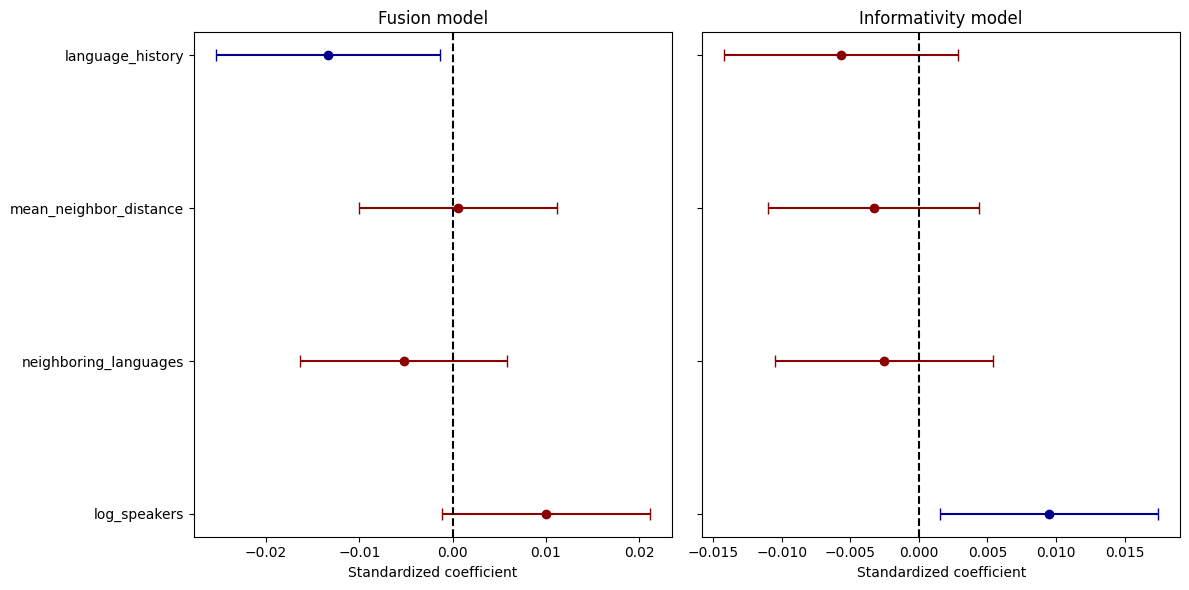

In [39]:
# ==========================================
# COEFFICIENT EXTRACTION
# ==========================================

coef_fusion = model_fusion.params
ci_fusion = model_fusion.conf_int()

coef_info = model_info.params
ci_info = model_info.conf_int()

# remove intercept
coef_fusion = coef_fusion.drop('Intercept')
ci_fusion = ci_fusion.drop('Intercept')

coef_info = coef_info.drop('Intercept')
ci_info = ci_info.drop('Intercept')

# remove random effect
coef_fusion = coef_fusion.drop('Group Var')
ci_fusion = ci_fusion.drop('Group Var')

coef_info = coef_info.drop('Group Var')
ci_info = ci_info.drop('Group Var')

# define variables after cleaning
variables = coef_fusion.index

# ==========================================
# FIGURE
# ==========================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 6),
    sharey=True
)

# ==========================================
# FUSION
# ==========================================

ax = axes[0]

y = np.arange(len(variables))

for i, var in enumerate(variables):

    coef = coef_fusion[var]
    low = ci_fusion.loc[var, 0]
    high = ci_fusion.loc[var, 1]

    # checking if significant
    significant = not (low <= 0 <= high)

    color = 'darkblue' if significant else 'darkred'

    ax.errorbar(
        x=coef,
        y=i,
        xerr=[[coef - low], [high - coef]],
        fmt='o',
        color=color,
        capsize=4
    )

ax.axvline(
    0,
    color='black',
    linestyle='--'
)

ax.set_yticks(y)
ax.set_yticklabels(variables)

ax.set_title("Fusion model")
ax.set_xlabel("Standardized coefficient")

# ==========================================
# INFORMATIVITY
# ==========================================

ax = axes[1]

for i, var in enumerate(variables):

    coef = coef_info[var]
    low = ci_info.loc[var, 0]
    high = ci_info.loc[var, 1]

    significant = not (low <= 0 <= high)

    color = 'darkblue' if significant else 'darkred'

    ax.errorbar(
        x=coef,
        y=i,
        xerr=[[coef - low], [high - coef]],
        fmt='o',
        color=color,
        capsize=4
    )

ax.axvline(
    0,
    color='black',
    linestyle='--'
)

ax.set_yticks(y)
ax.set_yticklabels(variables)

ax.set_title("Informativity model")
ax.set_xlabel("Standardized coefficient")

# ==========================================
# FINAL
# ==========================================

plt.tight_layout()
plt.show()

**Figure 2** - Forest plot with the results of this analysis

## 6. Conclusion

**Conclusion**: The results, once the linguistic families are taken into account as random effects, show that language history has a significant negative effect on morphological Fusion (see **Table 1.** and **Figure 2.**, $\beta_i = -0.013$, $p = .029$) while the number of speakers has a positive correlation with Informativity (see **Table 2.** and **Figure 2.**, $\beta_i = .010$, $p = .019$).
Our results therefore do not support the idea that the number of speakers of a language is correlated with a loss in morphological complexity across languages. Indeed, we do not find the negative correlation predicted, but instead a positive one (the other way).

**Limits**: It is important to note that this study has a few limits, including the fact that the measurement of the length of the phylogeny tree is a rather imperfect measurement for the effect of language history (since it remains very sensitive to how much more a language has been studied compared to others). The same goes for the other variables used which use annotations on language and are very sensitive to the study difference too.

Moreover, the analysis had to focus on a rather restrained amount of languages, since we had to rely on Wikidata's data on the number of speakers (which did not include L2 speakers, another important aspect of Lupyan & Dale's theory).

##  7. Bibliography

- Shcherbakova, Olena, Susanne Maria Michaelis, Hannah J. Haynie, Sam Passmore, Volker Gast, Russell D. Gray, Simon J. Greenhill, Damián E. Blasi, et Hedvig Skirgård. 2023. « Societies of Strangers Do Not Speak Less Complex Languages ». Science Advances 9(33): eadf7704. doi:10.1126/sciadv.adf7704.

- Lupyan, Gary, et Rick Dale. 2010. « Language Structure Is Partly Determined by Social Structure » éd. Dennis O’Rourke. PLoS ONE 5(1): e8559. doi:10.1371/journal.pone.0008559.

- Urban, Matthias. 2020. « Mountain Linguistics ». Language and Linguistics Compass 14(9):e12393. doi:10.1111/lnc3.12393.

- Everett, Caleb. 2013. « Evidence for Direct Geographic Influences on Linguistic Sounds: The Case of Ejectives » édité par M. Aronoff. PLoS ONE 8(6):e65275. doi:10.1371/journal.pone.0065275.